# 最终 OL 预测与圆环解析解对比

本 Notebook 只加载训练完成的 FE/OL 参数，比较以下边值问题的 SNO 预测与解析解：

$$
ΔP-k^2P=0,
P(r_out, theta)=0,
-P_r(r_in, theta)=alpha cos(theta).
$$

输出包括误差指标、预测/真解/绝对误差场图、径向与周向剖面对比，以及 SVG、PDF、PNG、NPZ 和 JSON 文件。

## Goal 与图形契约

- 核心结论：检查最终 SNO 是否在整个圆环内重构了解析压力场及其余弦角向结构。
- 证据链：预测场 → 解析场 → 点态绝对误差 → 径向/周向剖面。
- 图形类型：定量网格。
- 色标规则：预测与解析解严格共享同一对称色标；绝对误差使用独立非负色标。
- 主指标：带面积元的相对 $L_2$；同时报告网格相对 $L_2$、相对 $L_∞$ 和 RMSE。

## Setup

### 1. 在导入 JAX 前设置环境

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # 多 GPU 服务器按需设置


### 2. 导入依赖并设置评估参数

`RUN_NAME=None` 时自动选择最近修改且包含 OL 参数的目录。正式归档时建议显式填写训练目录名。

In [2]:
from dataclasses import fields
from pathlib import Path
import gc
import json
import sys

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from flax import serialization
from IPython.display import Markdown, display

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "config_polar.py").exists():
    raise FileNotFoundError("请把 Notebook 放在 polar_annulus_p_prior_ablation 根目录。")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

RUN_NAME = None  # 例如："polar_p_raw_seed0_ol_lowmem_s8_from_fe_step_000100000"
K_VALUE = 1.0
FLUX_AMPLITUDE = 1.0
PLOT_RADIAL_CELLS = 128
PLOT_THETA_CELLS = 256
DECODE_CHUNK_SIZE = 8192

OUTPUT_ROOT = PROJECT_DIR / "out_p_prior_ablation"
if RUN_NAME is None:
    candidates = [
        path for path in OUTPUT_ROOT.iterdir()
        if path.is_dir()
        and (path / "config.json").exists()
        and ((path / "ol_params.msgpack").exists()
             or (path / "ol_checkpoint_latest.msgpack").exists())
    ]
    if not candidates:
        raise FileNotFoundError("没有找到已训练的 OL 输出目录，请设置 RUN_NAME。")
    RUN_DIR = max(candidates, key=lambda path: path.stat().st_mtime)
    RUN_NAME = RUN_DIR.name
else:
    RUN_DIR = OUTPUT_ROOT / RUN_NAME

EVAL_DIR = RUN_DIR / "exact_solution_visualization"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
print("Project:", PROJECT_DIR)
print("Run directory:", RUN_DIR)
print("Evaluation directory:", EVAL_DIR)
print("JAX devices:", jax.devices())

Project: /home/user/data/Hollon/海洋工程水动力/polar_annulus_p_prior_ablation
Run directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_p_prior_ablation/out_p_prior_ablation/polar_p_raw_seed0
Evaluation directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_p_prior_ablation/out_p_prior_ablation/polar_p_raw_seed0/exact_solution_visualization
JAX devices: [CudaDevice(id=0)]


## Steps

### 3. 恢复训练配置

In [3]:
from config_polar import PolarAnnulusConfig

config_path = RUN_DIR / "config.json"
if not config_path.exists():
    raise FileNotFoundError(f"找不到训练配置：{config_path}")
saved_config = json.loads(config_path.read_text(encoding="utf-8"))
valid_fields = {field.name for field in fields(PolarAnnulusConfig)}
config_kwargs = {key: value for key, value in saved_config.items() if key in valid_fields}
if "prior_scale_pairs" in config_kwargs:
    config_kwargs["prior_scale_pairs"] = tuple(
        tuple(pair) for pair in config_kwargs["prior_scale_pairs"]
    )
for key in ("cnn_channels", "cnn_kernel_size", "cnn_stride"):
    if key in config_kwargs:
        config_kwargs[key] = tuple(config_kwargs[key])
config_kwargs["out_dir"] = str(OUTPUT_ROOT)
config_kwargs["run_name"] = RUN_NAME
cfg = PolarAnnulusConfig(**config_kwargs)

if not cfg.k_min <= K_VALUE <= cfg.k_max:
    raise ValueError(f"K_VALUE={K_VALUE} 超出训练范围 [{cfg.k_min}, {cfg.k_max}]。")
if PLOT_RADIAL_CELLS < 2 or PLOT_THETA_CELLS < 8 or DECODE_CHUNK_SIZE <= 0:
    raise ValueError("绘图网格或分块大小设置不合法。")
print(f"Geometry: r in [{cfg.r_inner}, {cfg.r_outer}]")
print(f"Training grid: {cfg.radial_size} x {cfg.theta_size}")
print(f"Evaluation: k={K_VALUE}, alpha={FLUX_AMPLITUDE}")

Geometry: r in [0.2, 1.0]
Training grid: 32 x 128
Evaluation: k=1.0, alpha=1.0


### 4. 只加载 FE/OL 参数

优先读取最终 `ol_params.msgpack`；若不存在，则从可续训 checkpoint 中只提取 OL 参数。不会恢复任何优化器状态。

In [4]:
from models_polar import FunctionEncoder, OperatorTransformer
from train_polar import load_normalizer

def load_params_only(path):
    restored = serialization.msgpack_restore(path.read_bytes())
    checkpoint_step = None
    if isinstance(restored, dict) and "state" in restored:
        checkpoint_step = int(restored["state"]["step"])
        raw_params = restored["state"]["params"]
    else:
        raw_params = restored
    params = jax.device_put(raw_params)
    jax.tree_util.tree_map(lambda value: value.block_until_ready(), params)
    del restored, raw_params
    gc.collect()
    return params, checkpoint_step

fe_path = RUN_DIR / "fe_params.msgpack"
if not fe_path.exists():
    raise FileNotFoundError(f"找不到 FE 参数快照：{fe_path}")
ol_final_path = RUN_DIR / "ol_params.msgpack"
ol_latest_path = RUN_DIR / "ol_checkpoint_latest.msgpack"
if ol_final_path.exists():
    ol_path = ol_final_path
    ol_status = "final"
elif ol_latest_path.exists():
    ol_path = ol_latest_path
    ol_status = "latest checkpoint"
else:
    raise FileNotFoundError("找不到 OL 参数或 checkpoint。")

fe_params, _ = load_params_only(fe_path)
ol_params, ol_checkpoint_step = load_params_only(ol_path)
normalizer = load_normalizer(RUN_DIR)
fe_model = FunctionEncoder(cfg)
ol_model = OperatorTransformer(cfg)
fe_count = sum(value.size for value in jax.tree_util.tree_leaves(fe_params))
ol_count = sum(value.size for value in jax.tree_util.tree_leaves(ol_params))
print("FE parameters:", f"{fe_count:,}")
print("OL parameters:", f"{ol_count:,}")
print("OL source:", ol_status, ol_path.name)
if ol_checkpoint_step is not None:
    print("OL checkpoint step:", ol_checkpoint_step)

FE parameters: 70,053,888
OL parameters: 13,991,936
OL source: latest checkpoint ol_checkpoint_latest.msgpack
OL checkpoint step: 140000


### 5. SNO 推理与高分辨率分块解码

In [5]:
from data_polar import (
    make_condition_tokens_from_arrays,
    make_source_tokens,
    make_target_cosine_boundary,
    normalize_f,
    r_to_hat,
    theta_to_hat,
)

zero_f = jnp.zeros((1, cfg.n_pod), dtype=jnp.float32)
latent_f = fe_model.apply(
    {"params": fe_params},
    normalize_f(zero_f, normalizer),
    method=FunctionEncoder.encode_f,
)
f_tokens = make_source_tokens(latent_f, cfg)
boundary_coords, boundary_flux = make_target_cosine_boundary(cfg, batch_size=1)
boundary_flux = FLUX_AMPLITUDE * boundary_flux
boundary_tokens = make_condition_tokens_from_arrays(
    boundary_coords, boundary_flux, cfg
)
k_values = jnp.asarray([K_VALUE], dtype=jnp.float32)
pred_latent_p = ol_model.apply(
    {"params": ol_params}, f_tokens, boundary_tokens, k_values
)
pred_latent_p.block_until_ready()
assert pred_latent_p.shape == (1, cfg.n_basis)
assert bool(jnp.all(jnp.isfinite(pred_latent_p)))
print("Predicted latent shape:", pred_latent_p.shape)

Predicted latent shape: (1, 512)


In [6]:
r_edges = np.linspace(cfg.r_inner, cfg.r_outer, PLOT_RADIAL_CELLS + 1)
theta_edges = np.linspace(0.0, 2.0 * np.pi, PLOT_THETA_CELLS + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
rr, tt = np.meshgrid(r_centers, theta_centers, indexing="ij")
coords_hat = np.stack(
    [
        np.asarray(theta_to_hat(jnp.asarray(tt))),
        np.asarray(r_to_hat(jnp.asarray(rr), cfg)),
    ],
    axis=-1,
).reshape(-1, 2).astype(np.float32)

@jax.jit
def decode_chunk(params, latent, coords):
    return fe_model.apply(
        {"params": params},
        latent,
        coords,
        method=FunctionEncoder.reconstruct_p,
    )

decoded_host_chunks = []
for start in range(0, coords_hat.shape[0], DECODE_CHUNK_SIZE):
    stop = min(start + DECODE_CHUNK_SIZE, coords_hat.shape[0])
    chunk = decode_chunk(
        fe_params, pred_latent_p, jnp.asarray(coords_hat[start:stop])
    )
    decoded_host_chunks.append(np.asarray(jax.device_get(chunk))[0])
p_pred_norm = np.concatenate(decoded_host_chunks)
mean_p = float(jax.device_get(normalizer.mean_p))
std_p = float(jax.device_get(normalizer.std_p))
p_pred = (p_pred_norm * std_p + mean_p).reshape(
    PLOT_RADIAL_CELLS, PLOT_THETA_CELLS
)
assert np.all(np.isfinite(p_pred))
print("Decoded field shape:", p_pred.shape)

Decoded field shape: (128, 256)


### 6. 解析解与误差指标

In [7]:
from exact_solution import exact_annulus_solution

p_exact = exact_annulus_solution(
    rr, tt, K_VALUE, cfg.r_inner, cfg.r_outer, FLUX_AMPLITUDE
)
signed_error = p_pred - p_exact
absolute_error = np.abs(signed_error)

def relative_l2(pred, ref, weights=None):
    if weights is None:
        weights = 1.0
    numerator = np.sum(weights * (pred - ref) ** 2)
    denominator = np.sum(weights * ref ** 2)
    return float(np.sqrt(numerator / max(denominator, np.finfo(float).tiny)))

grid_relative_l2 = relative_l2(p_pred, p_exact)
area_relative_l2 = relative_l2(p_pred, p_exact, rr)
rmse = float(np.sqrt(np.mean(signed_error ** 2)))
max_absolute_error = float(np.max(absolute_error))
relative_linf = max_absolute_error / max(
    float(np.max(np.abs(p_exact))), np.finfo(float).tiny
)
metrics = {
    "run_name": RUN_NAME,
    "ol_source": ol_status,
    "ol_checkpoint_step": ol_checkpoint_step,
    "k_value": float(K_VALUE),
    "flux_amplitude": float(FLUX_AMPLITUDE),
    "grid_relative_l2": grid_relative_l2,
    "area_weighted_relative_l2": area_relative_l2,
    "relative_linf": float(relative_linf),
    "rmse": rmse,
    "max_absolute_error": max_absolute_error,
}
for name, value in metrics.items():
    if isinstance(value, float):
        print(f"{name:30s}: {value:.8e}")
    else:
        print(f"{name:30s}: {value}")

run_name                      : polar_p_raw_seed0
ol_source                     : latest checkpoint
ol_checkpoint_step            : 140000
k_value                       : 1.00000000e+00
flux_amplitude                : 1.00000000e+00
grid_relative_l2              : 1.78955168e-01
area_weighted_relative_l2     : 2.25345559e-01
relative_linf                 : 1.12845396e-01
rmse                          : 8.48958359e-03
max_absolute_error            : 1.97812421e-02


## Results

### 7. 预测场、解析场与绝对误差

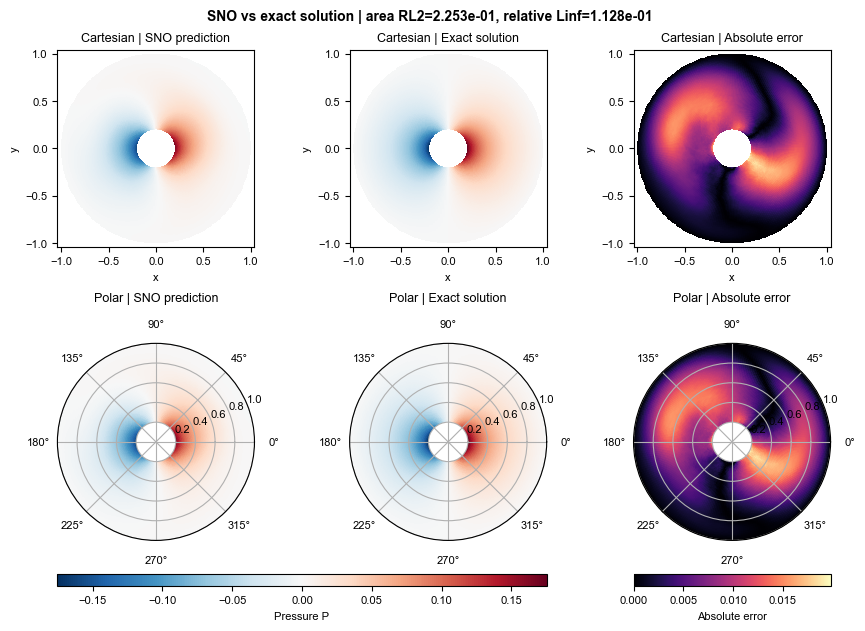

In [8]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "sans-serif"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.8,
})
solution_limit = max(
    float(np.max(np.abs(p_pred))),
    float(np.max(np.abs(p_exact))),
    np.finfo(float).eps,
)
solution_norm = mpl.colors.TwoSlopeNorm(
    vmin=-solution_limit, vcenter=0.0, vmax=solution_limit
)
error_norm = mpl.colors.Normalize(
    vmin=0.0, vmax=max(float(np.max(absolute_error)), np.finfo(float).eps)
)
rr_edges, tt_edges = np.meshgrid(r_edges, theta_edges, indexing="ij")
x_edges = rr_edges * np.cos(tt_edges)
y_edges = rr_edges * np.sin(tt_edges)
fields_to_plot = [p_pred, p_exact, absolute_error]
titles = ["SNO prediction", "Exact solution", "Absolute error"]

field_figure = plt.figure(figsize=(8.6, 6.2), layout="constrained")
layout = field_figure.add_gridspec(3, 3, height_ratios=(1, 1, 0.06))
cartesian_axes = [field_figure.add_subplot(layout[0, i]) for i in range(3)]
polar_axes = [
    field_figure.add_subplot(layout[1, i], projection="polar")
    for i in range(3)
]
meshes = []
for index, (axis, field, title) in enumerate(zip(cartesian_axes, fields_to_plot, titles)):
    is_error = index == 2
    mesh = axis.pcolormesh(
        x_edges, y_edges, field, shading="flat",
        cmap="magma" if is_error else "RdBu_r",
        norm=error_norm if is_error else solution_norm, rasterized=True,
    )
    meshes.append(mesh)
    axis.set_aspect("equal")
    axis.set(xlabel="x", ylabel="y", title=f"Cartesian | {title}")
    margin = 1.04 * cfg.r_outer
    axis.set_xlim(-margin, margin)
    axis.set_ylim(-margin, margin)
for index, (axis, field, title) in enumerate(zip(polar_axes, fields_to_plot, titles)):
    is_error = index == 2
    axis.pcolormesh(
        theta_edges, r_edges, field, shading="flat",
        cmap="magma" if is_error else "RdBu_r",
        norm=error_norm if is_error else solution_norm, rasterized=True,
    )
    axis.set_ylim(0.0, cfg.r_outer)
    axis.set_theta_zero_location("E")
    axis.set_theta_direction(1)
    axis.set_title(f"Polar | {title}", pad=13)
solution_cax = field_figure.add_subplot(layout[2, 0:2])
error_cax = field_figure.add_subplot(layout[2, 2])
field_figure.colorbar(meshes[0], cax=solution_cax, orientation="horizontal").set_label("Pressure P")
field_figure.colorbar(meshes[2], cax=error_cax, orientation="horizontal").set_label("Absolute error")
field_figure.suptitle(
    f"SNO vs exact solution | area RL2={area_relative_l2:.3e}, "
    f"relative Linf={relative_linf:.3e}",
    fontsize=10, fontweight="bold",
)
# field_base = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}_fields"
# field_figure.savefig(field_base.with_suffix(".svg"), bbox_inches="tight")
# field_figure.savefig(field_base.with_suffix(".pdf"), bbox_inches="tight")
# field_figure.savefig(field_base.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.show()

### 8. 径向与周向剖面对比

径向剖面在 $θ=0,π/2,π,3π/2$ 处比较；周向剖面在 $r=0.2,0.4,0.6,0.8$ 处比较。颜色表示角度或半径，实线和虚线分别表示 SNO 预测与解析解。

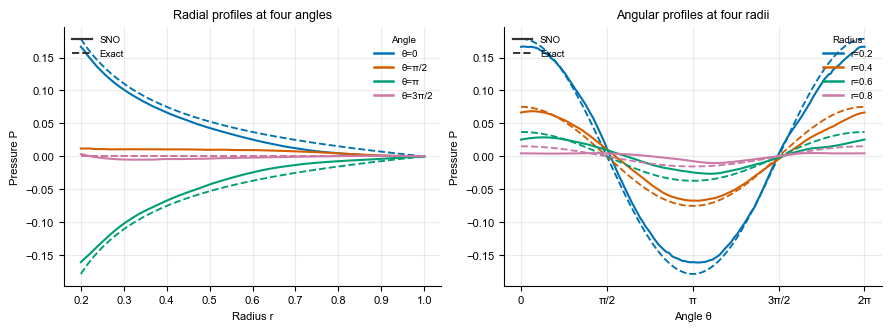

In [9]:
from matplotlib.lines import Line2D

def decode_pressure_at(radius, angle):
    radius = np.asarray(radius, dtype=np.float32)
    angle = np.asarray(angle, dtype=np.float32)
    if radius.shape != angle.shape:
        raise ValueError("radius and angle must have the same shape.")
    profile_coords_hat = np.stack(
        [
            np.asarray(theta_to_hat(jnp.asarray(angle))),
            np.asarray(r_to_hat(jnp.asarray(radius), cfg)),
        ],
        axis=-1,
    ).reshape(-1, 2).astype(np.float32)
    decoded_chunks = []
    for start in range(0, profile_coords_hat.shape[0], DECODE_CHUNK_SIZE):
        stop = min(start + DECODE_CHUNK_SIZE, profile_coords_hat.shape[0])
        chunk = decode_chunk(
            fe_params,
            pred_latent_p,
            jnp.asarray(profile_coords_hat[start:stop]),
        )
        decoded_chunks.append(np.asarray(jax.device_get(chunk))[0])
    pressure_norm = np.concatenate(decoded_chunks)
    return (pressure_norm * std_p + mean_p).reshape(radius.shape)

radial_profile_angles = np.asarray(
    [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi], dtype=np.float32
)
radial_angle_labels = ["0", "π/2", "π", "3π/2"]
radial_profile_r = np.linspace(
    cfg.r_inner, cfg.r_outer, PLOT_RADIAL_CELLS + 1, dtype=np.float32
)
radial_rr, radial_tt = np.meshgrid(
    radial_profile_r, radial_profile_angles, indexing="ij"
)
radial_pred = decode_pressure_at(radial_rr, radial_tt)
radial_exact = exact_annulus_solution(
    radial_rr, radial_tt, K_VALUE, cfg.r_inner, cfg.r_outer, FLUX_AMPLITUDE
)

angular_profile_radii = np.asarray([0.2, 0.4, 0.6, 0.8], dtype=np.float32)
if np.any(angular_profile_radii < cfg.r_inner) or np.any(
    angular_profile_radii > cfg.r_outer
):
    raise ValueError(
        f"Requested radii must lie in [{cfg.r_inner}, {cfg.r_outer}]."
    )
angular_profile_theta = np.linspace(
    0.0, 2.0 * np.pi, PLOT_THETA_CELLS + 1, dtype=np.float32
)
angular_rr, angular_tt = np.meshgrid(
    angular_profile_radii, angular_profile_theta, indexing="ij"
)
angular_pred = decode_pressure_at(angular_rr, angular_tt)
angular_exact = exact_annulus_solution(
    angular_rr, angular_tt, K_VALUE, cfg.r_inner, cfg.r_outer, FLUX_AMPLITUDE
)

profile_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
profile_figure, profile_axes = plt.subplots(
    1, 2, figsize=(8.8, 3.2), layout="constrained"
)
for index, (angle, label, color) in enumerate(
    zip(radial_profile_angles, radial_angle_labels, profile_colors)
):
    profile_axes[0].plot(
        radial_profile_r, radial_pred[:, index], color=color, lw=1.5
    )
    profile_axes[0].plot(
        radial_profile_r, radial_exact[:, index], color=color, ls="--", lw=1.35
    )
for index, (radius, color) in enumerate(
    zip(angular_profile_radii, profile_colors)
):
    profile_axes[1].plot(
        angular_profile_theta, angular_pred[index], color=color, lw=1.5
    )
    profile_axes[1].plot(
        angular_profile_theta, angular_exact[index], color=color, ls="--", lw=1.35
    )

profile_axes[0].set(
    xlabel="Radius r", ylabel="Pressure P",
    title="Radial profiles at four angles",
)
profile_axes[1].set(
    xlabel="Angle θ", ylabel="Pressure P",
    title="Angular profiles at four radii",
)
profile_axes[1].set_xticks(
    [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi],
    ["0", "π/2", "π", "3π/2", "2π"],
)
angle_handles = [
    Line2D([0], [0], color=color, lw=1.8, label=f"θ={label}")
    for label, color in zip(radial_angle_labels, profile_colors)
]
radius_handles = [
    Line2D([0], [0], color=color, lw=1.8, label=f"r={radius:.1f}")
    for radius, color in zip(angular_profile_radii, profile_colors)
]
style_handles = [
    Line2D([0], [0], color="0.2", lw=1.6, label="SNO"),
    Line2D([0], [0], color="0.2", ls="--", lw=1.4, label="Exact"),
]
for axis, value_handles, value_title in zip(
    profile_axes, [angle_handles, radius_handles], ["Angle", "Radius"]
):
    axis.grid(alpha=0.25)
    axis.spines[["top", "right"]].set_visible(False)
    value_legend = axis.legend(
        handles=value_handles, title=value_title, loc="upper right",
        frameon=False, fontsize=7, title_fontsize=7,
    )
    axis.add_artist(value_legend)
    axis.legend(
        handles=style_handles, loc="upper left", frameon=False, fontsize=7
    )
# profile_base = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}_profiles"
# profile_figure.savefig(profile_base.with_suffix(".svg"), bbox_inches="tight")
# profile_figure.savefig(profile_base.with_suffix(".pdf"), bbox_inches="tight")
# profile_figure.savefig(profile_base.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.show()

### 9. 保存数值结果

In [ ]:
array_path = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}.npz"
metrics_path = EVAL_DIR / f"sno_vs_exact_k_{K_VALUE:g}_metrics.json"
np.savez_compressed(
    array_path,
    r=r_centers, theta=theta_centers,
    x=rr * np.cos(tt), y=rr * np.sin(tt),
    p_pred=p_pred, p_exact=p_exact,
    signed_error=signed_error, absolute_error=absolute_error,
)
metrics_path.write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8"
)
print("Saved arrays:", array_path)
print("Saved metrics:", metrics_path)
print("Saved figures under:", EVAL_DIR)

## Takeaways

In [ ]:
display(Markdown(f"""
本次评估使用 **{ol_status}**，测试参数为 $k={K_VALUE:g}$、$α={FLUX_AMPLITUDE:g}$。

- 网格相对 $L_2$：**{grid_relative_l2:.4e}**
- 面积加权相对 $L_2$：**{area_relative_l2:.4e}**
- 相对 $L_∞$：**{relative_linf:.4e}**
- RMSE：**{rmse:.4e}**

预测解和解析解使用同一色标，误差场使用独立非负色标；剖面图用于检查径向衰减和余弦角向结构。
"""))

## Next Steps

- 若自动选择了错误目录，请显式设置 `RUN_NAME` 后从配置单元重新运行。
- GPU 显存不足时只需减小 `DECODE_CHUNK_SIZE`，不会改变数值结果。
- 若训练覆盖多个 $k$，可修改 `K_VALUE` 后重复评估。